# QuantRisk AI — Module 4: ML Risk Model

Predict whether the **next 20 trading days** will have elevated realized volatility.

Key safeguards:
- The 2020–2025 master dataset is loaded but not overwritten.
- Chronological Train/Validation/Test split: 2020–2023 / 2024 / 2025.
- High-risk threshold is learned from training data only.
- Full-period Module 3 Beta is not used; causal expanding Beta is calculated.
- Imputer and scaler are fitted on training data only.

In [6]:
import os
import warnings
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
HORIZON = 20

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the unchanged master dataset

In [7]:
# ============================================================
# 2. Project root
# ============================================================

PROJECT_ROOT = Path(
    r"C:\Users\Nalavade\PycharmProjects\Py_Portfolio_NLP"
)

# ============================================================
# 3. Project folders
# ============================================================

DATA_DIR = PROJECT_ROOT / "backend" / "data"
MODEL_DIR = PROJECT_ROOT / "backend" / "models"

# Create model directory if it does not already exist
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# 4. Input dataset
# ============================================================

MASTER_PATH = DATA_DIR / "master_dataset.csv"

# ============================================================
# 5. Output artifact paths
# ============================================================

MODEL_PATH = MODEL_DIR / "quant_risk_model.pkl"
RESULTS_PATH = MODEL_DIR / "model_results.csv"
IMPORTANCE_PATH = MODEL_DIR / "feature_importance.csv"

OUTPUT_PATH = DATA_DIR / "feature_engineered_dataset.csv"

# ============================================================
# 6. Verify project paths
# ============================================================

print("Project root:")
print(PROJECT_ROOT)

print("\nData directory:")
print(DATA_DIR)

print("\nModel directory:")
print(MODEL_DIR)

print("\nMaster dataset:")
print(MASTER_PATH)

print("\nModel output:")
print(MODEL_PATH)

# Check that the master dataset exists
if not MASTER_PATH.exists():
    raise FileNotFoundError(
        f"\nmaster_dataset.csv was not found at:\n{MASTER_PATH}\n"
        f"\nPlease verify that the file exists in:\n{DATA_DIR}"
    )

print("\nMaster dataset found successfully.")


df = pd.read_csv(MASTER_PATH, parse_dates=["Date"])
df = df.sort_values(["Stock", "Date"]).reset_index(drop=True)

required_cols = [
    "Date", "Stock", "Open", "High", "Low", "Close",
    "Volume", "NIFTY_Close", "VIX_Close"
]

missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

print("Shape:", df.shape)
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Stocks:", df["Stock"].nunique())
print("Missing required values:", df[required_cols].isna().sum().sum())
print("Duplicate Stock-Date rows:", df.duplicated(["Stock", "Date"]).sum())

Project root:
C:\Users\Nalavade\PycharmProjects\Py_Portfolio_NLP

Data directory:
C:\Users\Nalavade\PycharmProjects\Py_Portfolio_NLP\backend\data

Model directory:
C:\Users\Nalavade\PycharmProjects\Py_Portfolio_NLP\backend\models

Master dataset:
C:\Users\Nalavade\PycharmProjects\Py_Portfolio_NLP\backend\data\master_dataset.csv

Model output:
C:\Users\Nalavade\PycharmProjects\Py_Portfolio_NLP\backend\models\quant_risk_model.pkl

Master dataset found successfully.
Shape: (70764, 9)
Date range: 2020-01-02 to 2025-12-31
Stocks: 49
Missing required values: 0
Duplicate Stock-Date rows: 0


## 3. Recreate Module 3 features

In [8]:
g = df.groupby("Stock", group_keys=False)

df["Daily_Return"] = g["Close"].pct_change()

df["Rolling_Volatility_20D"] = g["Daily_Return"].transform(
    lambda x: x.rolling(20, min_periods=20).std()
)
df["Rolling_Volatility_60D"] = g["Daily_Return"].transform(
    lambda x: x.rolling(60, min_periods=60).std()
)

df["MA_20"] = g["Close"].transform(
    lambda x: x.rolling(20, min_periods=20).mean()
)
df["MA_50"] = g["Close"].transform(
    lambda x: x.rolling(50, min_periods=50).mean()
)

df["Price_MA20_Ratio"] = df["Close"] / df["MA_20"]
df["Price_MA50_Ratio"] = df["Close"] / df["MA_50"]
df["Momentum_20D"] = g["Close"].transform(lambda x: x.pct_change(20))

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period, min_periods=period).mean()
    avg_loss = loss.rolling(period, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df["RSI_14"] = g["Close"].transform(calculate_rsi)

df["EMA_12"] = g["Close"].transform(
    lambda x: x.ewm(span=12, adjust=False).mean()
)
df["EMA_26"] = g["Close"].transform(
    lambda x: x.ewm(span=26, adjust=False).mean()
)
df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["MACD_Signal"] = g["MACD"].transform(
    lambda x: x.ewm(span=9, adjust=False).mean()
)
df["MACD_Histogram"] = df["MACD"] - df["MACD_Signal"]

df["Previous_Close"] = g["Close"].shift(1)

tr = pd.concat([
    df["High"] - df["Low"],
    (df["High"] - df["Previous_Close"]).abs(),
    (df["Low"] - df["Previous_Close"]).abs()
], axis=1)
df["TR"] = tr.max(axis=1)

df["ATR_14"] = g["TR"].transform(
    lambda x: x.rolling(14, min_periods=14).mean()
)

df["Volatility_Ratio"] = (
    df["Rolling_Volatility_20D"] / df["Rolling_Volatility_60D"]
)

df["Volume_MA20"] = g["Volume"].transform(
    lambda x: x.rolling(20, min_periods=20).mean()
)
df["Volume_Ratio"] = df["Volume"] / df["Volume_MA20"]
df["Volume_Change"] = g["Volume"].pct_change()
df["Volume_Change"] = df["Volume_Change"].replace([np.inf, -np.inf], np.nan)

df["Price_Range"] = df["High"] - df["Low"]
df["High_Low_Pct"] = (df["High"] - df["Low"]) / df["Close"]
df["Gap_Pct"] = (
    (df["Open"] - df["Previous_Close"]) / df["Previous_Close"]
)

print("Module 3 features recreated.")
print("Rows:", len(df))
print("Infinite numeric values:",
      np.isinf(df.select_dtypes(include=np.number)).sum().sum())

Module 3 features recreated.
Rows: 70764
Infinite numeric values: 0


## 4. Leakage-safe market Beta

The Module 3 Beta used the complete 2020–2025 period. That is unsuitable as a historical predictor because later observations can influence earlier rows.

Here Beta at date **t** uses only stock and NIFTY returns available **before t**, with at least 60 prior observations.

In [9]:
nifty = (
    df[["Date", "NIFTY_Close"]]
    .drop_duplicates("Date")
    .sort_values("Date")
    .copy()
)
nifty["NIFTY_Return"] = nifty["NIFTY_Close"].pct_change()

df = df.merge(
    nifty[["Date", "NIFTY_Return"]],
    on="Date",
    how="left",
    validate="many_to_one"
)

MIN_BETA_OBS = 60

def causal_expanding_beta(group):
    stock_r = group["Daily_Return"]
    market_r = group["NIFTY_Return"]

    # Strictly historical returns only.
    stock_hist = stock_r.shift(1)
    market_hist = market_r.shift(1)

    covariance = stock_hist.expanding(
        min_periods=MIN_BETA_OBS
    ).cov(market_hist)

    market_variance = market_hist.expanding(
        min_periods=MIN_BETA_OBS
    ).var()

    return covariance / market_variance

beta_series = (
    df.groupby("Stock", group_keys=False)
      .apply(causal_expanding_beta, include_groups=False)
)

df["Beta_Causal"] = beta_series.reset_index(level=0, drop=True)
df = df.sort_values(["Stock", "Date"]).reset_index(drop=True)

print("Causal Beta created.")
print("Valid:", df["Beta_Causal"].notna().sum())
print("NaN:", df["Beta_Causal"].isna().sum())

Causal Beta created.
Valid: 67775
NaN: 2989


## 5. Define the future risk target

The target is future 20-trading-day realized volatility:

**FutureVol(t) = std(Return(t+1), ..., Return(t+20))**

High risk is defined as future volatility above the **75th percentile of the training period**.

The threshold is learned only from training data.

In [10]:
# ============================================================
# 5. Create a leakage-safe future-volatility target
# ============================================================

# For each observation t, the target is the standard deviation of
# returns t+1 ... t+20 for the SAME stock.
#
# We explicitly construct the forward window so there is no ambiguity
# about alignment.

def forward_std(values, horizon=20):
    values = np.asarray(values, dtype=float)
    out = np.full(len(values), np.nan)

    for i in range(len(values) - horizon):
        future_returns = values[i + 1:i + 1 + horizon]

        # Require a complete horizon.
        if np.isfinite(future_returns).all():
            out[i] = np.std(future_returns, ddof=1)

    return out

df["Future_Volatility_20D"] = (
    df.groupby("Stock")["Daily_Return"]
      .transform(
          lambda x: pd.Series(
              forward_std(x.to_numpy(), HORIZON),
              index=x.index
          )
      )
)

print("Future volatility target created.")
print("Valid targets:", df["Future_Volatility_20D"].notna().sum())
print("Missing targets:", df["Future_Volatility_20D"].isna().sum())

Future volatility target created.
Valid targets: 69784
Missing targets: 980


## 6. Chronological Train / Validation / Test split

In [11]:
# ============================================================
# 6. Chronological split with a 20-day purge at boundaries
# ============================================================

TRAIN_END = pd.Timestamp("2023-12-31")
VAL_END = pd.Timestamp("2024-12-31")

# A label at date t needs returns through t+20.
# Therefore training observations near 2023-12-31 are excluded from
# threshold/model fitting if their target window enters 2024.
# Likewise, validation observations whose target enters 2025 are
# excluded from validation evaluation.
#
# This is a standard purging idea for time-series ML.

train_feature_mask = df["Date"] <= TRAIN_END
val_feature_mask = (df["Date"] > TRAIN_END) & (df["Date"] <= VAL_END)
test_feature_mask = df["Date"] > VAL_END

train_label_mask = (
    train_feature_mask &
    df["Future_Volatility_20D"].notna() &
    (df["Date"] <= TRAIN_END - pd.offsets.BDay(HORIZON))
)

val_label_mask = (
    val_feature_mask &
    df["Future_Volatility_20D"].notna() &
    (df["Date"] <= VAL_END - pd.offsets.BDay(HORIZON))
)

test_label_mask = (
    test_feature_mask &
    df["Future_Volatility_20D"].notna()
)

print("TRAIN feature period:")
print(df.loc[train_feature_mask, "Date"].min().date(),
      "to", df.loc[train_feature_mask, "Date"].max().date())

print("\nTRAIN usable labeled period:")
print(df.loc[train_label_mask, "Date"].min().date(),
      "to", df.loc[train_label_mask, "Date"].max().date(),
      "| rows:", train_label_mask.sum())

print("\nVALIDATION feature period:")
print(df.loc[val_feature_mask, "Date"].min().date(),
      "to", df.loc[val_feature_mask, "Date"].max().date())

print("\nVALIDATION usable labeled period:")
print(df.loc[val_label_mask, "Date"].min().date(),
      "to", df.loc[val_label_mask, "Date"].max().date(),
      "| rows:", val_label_mask.sum())

print("\nTEST usable labeled period:")
print(df.loc[test_label_mask, "Date"].min().date(),
      "to", df.loc[test_label_mask, "Date"].max().date(),
      "| rows:", test_label_mask.sum())

TRAIN feature period:
2020-01-02 to 2023-12-29

TRAIN usable labeled period:
2020-01-02 to 2023-12-04 | rows: 45823

VALIDATION feature period:
2024-01-02 to 2024-12-31

VALIDATION usable labeled period:
2024-01-02 to 2024-12-03 | rows: 11025

TEST usable labeled period:
2025-01-02 to 2025-12-02 | rows: 11123


In [12]:
# ============================================================
# 7. Learn risk threshold from TRAIN labels only
# ============================================================

TARGET_QUANTILE = 0.75

risk_threshold = (
    df.loc[train_label_mask, "Future_Volatility_20D"]
      .quantile(TARGET_QUANTILE)
)

# Create labels only where the corresponding future target exists.
df["High_Risk"] = np.nan
valid_target = df["Future_Volatility_20D"].notna()

df.loc[valid_target, "High_Risk"] = (
    df.loc[valid_target, "Future_Volatility_20D"] > risk_threshold
).astype(int)

print(f"Training risk threshold: {risk_threshold:.6f}")
print(f"Training threshold as percentage: {risk_threshold:.2%}")

print("\nTRAIN target distribution:")
print(df.loc[train_label_mask, "High_Risk"].value_counts().sort_index())

print("\nVALIDATION target distribution:")
print(df.loc[val_label_mask, "High_Risk"].value_counts().sort_index())

print("\nTEST target distribution:")
print(df.loc[test_label_mask, "High_Risk"].value_counts().sort_index())

Training risk threshold: 0.022027
Training threshold as percentage: 2.20%

TRAIN target distribution:
High_Risk
0.0    34367
1.0    11456
Name: count, dtype: int64

VALIDATION target distribution:
High_Risk
0.0    9602
1.0    1423
Name: count, dtype: int64

TEST target distribution:
High_Risk
0.0    10288
1.0      835
Name: count, dtype: int64


## 7. Correlation-filtered candidate features

In [13]:
selected_features = [
    "Daily_Return",
    "Rolling_Volatility_20D",
    "Rolling_Volatility_60D",
    "Price_MA20_Ratio",
    "Price_MA50_Ratio",
    "Momentum_20D",
    "RSI_14",
    "MACD",
    "MACD_Histogram",
    "ATR_14",
    "Beta_Causal",
    "Volatility_Ratio",
    "Volume_MA20",
    "Volume_Ratio",
    "Volume_Change",
    "Price_Range",
    "High_Low_Pct",
    "Gap_Pct"
]

print("Candidate feature count:", len(selected_features))
for i, feature in enumerate(selected_features, 1):
    print(f"{i:2d}. {feature}")

Candidate feature count: 18
 1. Daily_Return
 2. Rolling_Volatility_20D
 3. Rolling_Volatility_60D
 4. Price_MA20_Ratio
 5. Price_MA50_Ratio
 6. Momentum_20D
 7. RSI_14
 8. MACD
 9. MACD_Histogram
10. ATR_14
11. Beta_Causal
12. Volatility_Ratio
13. Volume_MA20
14. Volume_Ratio
15. Volume_Change
16. Price_Range
17. High_Low_Pct
18. Gap_Pct


## 8. Build modeling data

Rows with no future target are excluded because a supervised model cannot be trained/evaluated without a label.

Feature NaNs are **not manually filled here**. They will be imputed using a pipeline fitted only on the training set.

In [14]:
# ============================================================
# 8. Build modeling data using purged chronological masks
# ============================================================

# Only labeled observations are used.
model_mask = train_label_mask | val_label_mask | test_label_mask
model_df = df.loc[model_mask].copy()

X = model_df[selected_features].copy()
y = model_df["High_Risk"].astype(int)

train_idx = train_label_mask.loc[model_df.index]
val_idx = val_label_mask.loc[model_df.index]
test_idx = test_label_mask.loc[model_df.index]

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_val, y_val = X.loc[val_idx], y.loc[val_idx]
X_test, y_test = X.loc[test_idx], y.loc[test_idx]

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (45823, 18)
X_val: (11025, 18)
X_test: (11123, 18)


## 9. Leakage-safe preprocessing

In [15]:
preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

print("Preprocessing fitted on TRAIN only.")
print("Training NaNs after preprocessing:", np.isnan(X_train_p).sum())

Preprocessing fitted on TRAIN only.
Training NaNs after preprocessing: 0


## 10. Train baseline models

In [16]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        max_features="sqrt",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    # "SVM": SVC(
    #     C=1.0,
    #     kernel="rbf",
    #     gamma="scale",
    #     probability=True,
    #     class_weight="balanced",
    #     random_state=RANDOM_STATE
    # )
}

def evaluate_model(model, X_data, y_data, split_name):
    pred = model.predict(X_data)
    prob = model.predict_proba(X_data)[:, 1]

    return {
        "Split": split_name,
        "Accuracy": accuracy_score(y_data, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_data, pred),
        "Precision": precision_score(y_data, pred, zero_division=0),
        "Recall": recall_score(y_data, pred, zero_division=0),
        "F1": f1_score(y_data, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_data, prob)
    }

results = []
fitted_models = {}

for name, model in models.items():
    print("Training:", name)
    model.fit(X_train_p, y_train)
    fitted_models[name] = model

    for split_name, Xp, yp in [
        ("Train", X_train_p, y_train),
        ("Validation", X_val_p, y_val),
        ("Test", X_test_p, y_test)
    ]:
        results.append(
            {"Model": name}
            | evaluate_model(model, Xp, yp, split_name)
        )

results_df = pd.DataFrame(results)

display(
    results_df[
        ["Model", "Split", "Accuracy", "Balanced_Accuracy",
         "Precision", "Recall", "F1", "ROC_AUC"]
    ].round(4)
)

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest


,Model,Split,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,Train,0.7747,0.7452,0.5389,0.6862,0.6037,0.8290
1,Logistic Regression,Validation,0.7890,0.6134,0.2714,0.3767,0.3155,0.7240
2,Logistic Regression,Test,0.8850,0.7128,0.3287,0.5102,0.3998,0.8549
3,Decision Tree,Train,0.7417,0.7687,0.4902,0.8227,0.6143,0.8593
4,Decision Tree,Validation,0.7440,0.6349,0.2490,0.4877,0.3297,0.6978
5,Decision Tree,Test,0.8358,0.7858,0.2753,0.7269,0.3993,0.8372
6,Random Forest,Train,0.8310,0.8339,0.6196,0.8396,0.7130,0.9223
7,Random Forest,Validation,0.7886,0.6176,0.2741,0.3872,0.3210,0.7115
8,Random Forest,Test,0.8780,0.7448,0.3265,0.5880,0.4198,0.8496


## 11. Validation and held-out test comparison

In [17]:
validation_results = (
    results_df[results_df["Split"] == "Validation"]
    .sort_values(["ROC_AUC", "F1", "Recall"], ascending=False)
    .reset_index(drop=True)
)

test_results = (
    results_df[results_df["Split"] == "Test"]
    .sort_values(["ROC_AUC", "F1", "Recall"], ascending=False)
    .reset_index(drop=True)
)

print("VALIDATION")
display(validation_results.round(4))

print("\nHELD-OUT 2025 TEST")
display(test_results.round(4))

VALIDATION


,Model,Split,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,Validation,0.7890,0.6134,0.2714,0.3767,0.3155,0.7240
1,Random Forest,Validation,0.7886,0.6176,0.2741,0.3872,0.3210,0.7115
2,Decision Tree,Validation,0.7440,0.6349,0.2490,0.4877,0.3297,0.6978



HELD-OUT 2025 TEST


,Model,Split,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,Test,0.8850,0.7128,0.3287,0.5102,0.3998,0.8549
1,Random Forest,Test,0.8780,0.7448,0.3265,0.5880,0.4198,0.8496
2,Decision Tree,Test,0.8358,0.7858,0.2753,0.7269,0.3993,0.8372


## 12. Confusion matrices on the test set


Logistic Regression
[[9418  870]
 [ 409  426]]


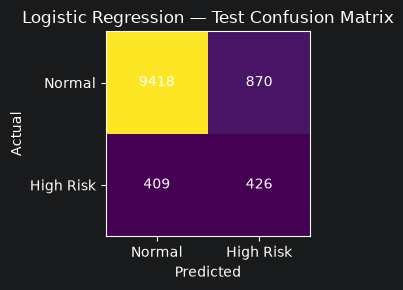


Decision Tree
[[8690 1598]
 [ 228  607]]


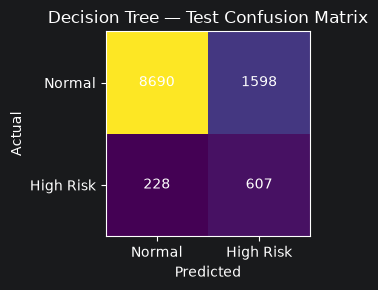


Random Forest
[[9275 1013]
 [ 344  491]]


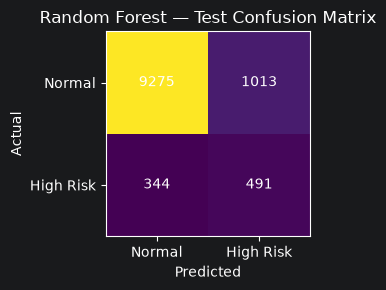

In [18]:
for name, model in fitted_models.items():
    pred = model.predict(X_test_p)
    cm = confusion_matrix(y_test, pred)

    print(f"\n{name}")
    print(cm)

    fig, ax = plt.subplots(figsize=(4, 3))
    im = ax.imshow(cm, interpolation="nearest")
    ax.set_title(f"{name} — Test Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1], ["Normal", "High Risk"])
    ax.set_yticks([0, 1], ["Normal", "High Risk"])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

## 13. ROC curves on the held-out test set

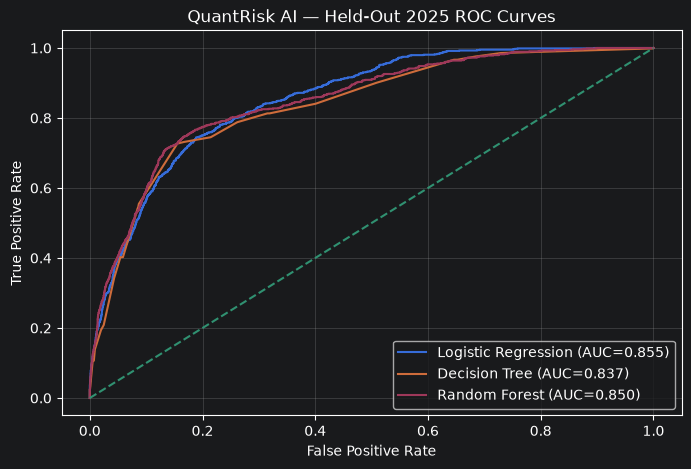

In [19]:
plt.figure(figsize=(8, 5))

for name, model in fitted_models.items():
    prob = model.predict_proba(X_test_p)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("QuantRisk AI — Held-Out 2025 ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 14. Feature importance

,Feature,Importance
2,Rolling_Volatility_60D,0.32931
1,Rolling_Volatility_20D,0.18760
10,Beta_Causal,0.11771
16,High_Low_Pct,0.09261
4,Price_MA50_Ratio,0.04339
12,Volume_MA20,0.04120
11,Volatility_Ratio,0.03319
9,ATR_14,0.03048
5,Momentum_20D,0.02782
7,MACD,0.02039


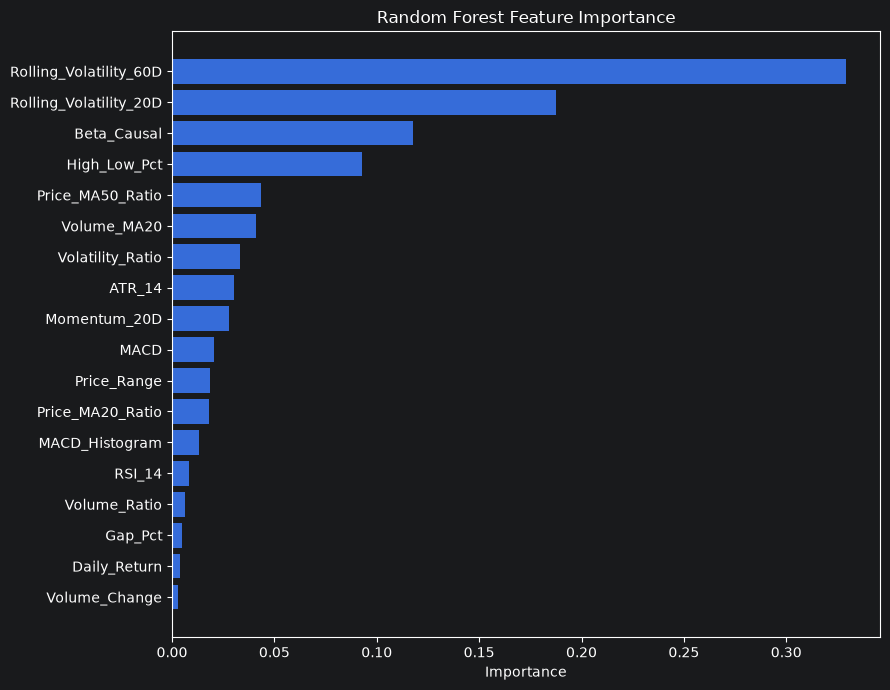

In [20]:
rf = fitted_models["Random Forest"]

importance_df = pd.DataFrame({
    "Feature": selected_features,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance_df.round(5))

plot_df = importance_df.sort_values("Importance")

plt.figure(figsize=(9, 7))
plt.barh(plot_df["Feature"], plot_df["Importance"])
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## 15. Logistic Regression coefficients

In [21]:
lr = fitted_models["Logistic Regression"]

coef_df = pd.DataFrame({
    "Feature": selected_features,
    "Coefficient": lr.coef_[0],
    "Abs_Coefficient": np.abs(lr.coef_[0])
}).sort_values("Abs_Coefficient", ascending=False)

display(coef_df.round(5))

,Feature,Coefficient,Abs_Coefficient
1,Rolling_Volatility_20D,1.50804,1.50804
16,High_Low_Pct,0.64048,0.64048
11,Volatility_Ratio,-0.47959,0.47959
4,Price_MA50_Ratio,0.40296,0.40296
10,Beta_Causal,0.29100,0.29100
15,Price_Range,-0.27677,0.27677
5,Momentum_20D,-0.24428,0.24428
3,Price_MA20_Ratio,-0.15974,0.15974
9,ATR_14,0.14433,0.14433
2,Rolling_Volatility_60D,-0.13318,0.13318


## 16. Select model using validation ROC-AUC

In [22]:
best_model_name = validation_results.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print("Validation-based selected model:", best_model_name)

selected_test = results_df[
    (results_df["Model"] == best_model_name) &
    (results_df["Split"] == "Test")
]

display(selected_test.round(4))

Validation-based selected model: Logistic Regression


,Model,Split,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC
2,Logistic Regression,Test,0.885,0.7128,0.3287,0.5102,0.3998,0.8549


## 17. Generate QuantRisk AI risk scores

In [23]:
# ============================================================
# 17. Generate QuantRisk AI risk scores
# ============================================================

test_predictions = model_df.loc[
    test_idx,
    ["Date", "Stock", "Close",
     "Future_Volatility_20D", "High_Risk"]
].copy()

test_predictions["Risk_Probability"] = (
    best_model.predict_proba(X_test_p)[:, 1]
)

test_predictions["Predicted_High_Risk"] = (
    test_predictions["Risk_Probability"] >= 0.50
).astype(int)

test_predictions = test_predictions.sort_values(
    "Risk_Probability", ascending=False
)

display(test_predictions.head(20).round(4))

,Date,Stock,Close,Future_Volatility_20D,High_Risk,Risk_Probability,Predicted_High_Risk
34704,2025-03-11,INDUSINDBK,654.8893,0.0271,1.0,1.0000,1
34705,2025-03-12,INDUSINDBK,683.5928,0.0294,1.0,0.9997,1
34721,2025-04-07,INDUSINDBK,674.8071,0.0277,1.0,0.9987,1
34717,2025-04-01,INDUSINDBK,681.5960,0.0290,1.0,0.9986,1
34713,2025-03-25,INDUSINDBK,636.0198,0.0320,1.0,0.9984,1
34706,2025-03-13,INDUSINDBK,671.2628,0.0325,1.0,0.9983,1
34715,2025-03-27,INDUSINDBK,672.4608,0.0317,1.0,0.9982,1
34716,2025-03-28,INDUSINDBK,648.7991,0.0298,1.0,0.9979,1
34707,2025-03-17,INDUSINDBK,676.3046,0.0325,1.0,0.9977,1
34718,2025-04-02,INDUSINDBK,701.3141,0.0294,1.0,0.9974,1


## 18. Save model artifacts for the QuantRisk AI dashboard

In [24]:
os.makedirs("models", exist_ok=True)

artifact = {
    "model": best_model,
    "preprocessor": preprocessor,
    "features": selected_features,
    "risk_threshold": float(risk_threshold),
    "risk_quantile": TARGET_QUANTILE,
    "horizon_days": HORIZON,
    "train_end": str(TRAIN_END.date()),
    "validation_end": str(VAL_END.date()),
    "target": "Future_Volatility_20D",
    "label": "High_Risk",
    "beta_definition": (
        "Expanding beta using only observations available "
        "before each prediction date"
    )
}

MODEL_PATH = "models/quant_risk_model.pkl"
RESULTS_PATH = "models/model_results.csv"
IMPORTANCE_PATH = "models/feature_importance.csv"

joblib.dump(artifact, MODEL_PATH)
results_df.to_csv(RESULTS_PATH, index=False)
importance_df.to_csv(IMPORTANCE_PATH, index=False)

print("Saved:")
print(MODEL_PATH)
print(RESULTS_PATH)
print(IMPORTANCE_PATH)

Saved:
models/quant_risk_model.pkl
models/model_results.csv
models/feature_importance.csv


In [25]:
df.to_csv(
    OUTPUT_PATH,
    index=False
)

print("Feature-engineered dataset saved successfully.")
print("Saved:", OUTPUT_PATH)
print("Exists:", OUTPUT_PATH.exists())
print("Shape:", df.shape)

Feature-engineered dataset saved successfully.
Saved: C:\Users\Nalavade\PycharmProjects\Py_Portfolio_NLP\backend\data\feature_engineered_dataset.csv
Exists: True
Shape: (70764, 37)


# Module 4 — Methodology Checklist

- Master dataset remains unchanged.
- Target is future 20-day realized volatility.
- Future target window is explicitly t+1 ... t+20.
- Risk threshold is learned from TRAIN labels only.
- Chronological Train/Validation/Test split is used.
- A 20-trading-day boundary purge prevents target windows from crossing
  train/validation/test boundaries.
- Full-period Module 3 Beta is excluded from ML.
- Causal expanding Beta is used.
- Imputation is fitted on TRAIN only.
- Scaling is fitted on TRAIN only.
- 2025 is the final held-out test period.
- Multiple classification metrics are reported.
- Confusion matrices and ROC curves are generated.
- Random Forest feature importance and Logistic Regression coefficients
  are generated.
- Model artifacts are saved for dashboard integration.

### Important note on feature selection

The 18 candidate features were identified during Module 3 using the
full 2020–2025 exploratory correlation matrix. This is acceptable for
the project's exploratory feature-engineering record, but for a strict
unseen-test research protocol, feature-selection decisions should also
be re-checked using TRAIN data only before finalizing the production
feature set. Module 4 therefore treats the 18 features as candidates;
later feature-selection/SHAP analysis should be based on training data.

### Prediction timing

Features are interpreted as information available at the end of day t.
The model predicts the volatility regime over the following 20 trading
days.

**Interpretation:** the model predicts an elevated-volatility regime,
not a guaranteed stock return or investment outcome.